In [2]:
import os
import random
import json
import copy
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer

print("Torch version:", torch.__version__)


Torch version: 2.9.0


In [3]:
SEED = 42
BATCH_SIZE_ENCODE = 2
TEXT_BATCH_SIZE_TRAIN = 128
NEG_K = 2
CONTRASTIVE_EPOCHS = 20
N_FOLDS = 10
EMBEDDING_MODEL = "google/embeddinggemma-300m"
FORCE_CPU = True
REG_WEIGHT = 0.1
LOW_SCORE_THRESH = 7.0
LOW_SCORE_MULT = 12.0
NEG_SCORE_THRESH = 6.0
TRAIN_JSON = "data/train_data.json"
TEST_JSON = "data/test_data.json"
METRIC_NAMES_JSON = "data/metric_names.json"
SAMPLE_SUB = "data/sample_submission.csv"

TRAIN_EMB_NPY = "saved_embeddings/train_text_embeddings.npy"
TEST_EMB_NPY = "saved_embeddings/test_text_embeddings.npy"
METRIC_EMB_NPY = "data/metric_name_embeddings.npy"


In [4]:
if FORCE_CPU:
    DEVICE = "cpu"
    print("Forcing CPU usage (FORCE_CPU=True)")
elif torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print("Using device:", DEVICE)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.startswith("cuda"):
    torch.cuda.manual_seed_all(SEED)


Forcing CPU usage (FORCE_CPU=True)
Using device: cpu


In [5]:
def load_json(path):
    """Load JSON file as pandas DataFrame."""
    return pd.read_json(path)

def load_metric_names(path):
    """Load metric names from JSON file."""
    with open(path, "r") as f:
        return json.load(f)

def format_document_input(system, user, response):
    """Format input text in Gemma document format."""
    content = f"{system} [SEP] {user} [SEP] {response}"
    return f"title: none | text: {content}"

def encode_texts_if_needed(texts, out_path, model, batch_size=BATCH_SIZE_ENCODE):
    """Encode texts using the model, with caching support."""
    out_p = Path(out_path)
    if out_p.exists():
        print(f"Loading cached embeddings from {out_path}")
        return np.load(out_path)
    print(f"Encoding {len(texts)} texts to {out_path} (batch_size={batch_size}) ...")
    embs = model.encode(texts, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)
    np.save(out_path, embs)
    print(f"Saved embeddings to {out_path}")
    return embs


In [6]:
class MetricModel(nn.Module):
    """Neural network model that combines text and metric embeddings to predict scores."""
    
    def __init__(self, text_dim, metric_dim, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(text_dim + metric_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, t, m):
        """Forward pass: concatenate text and metric embeddings, return raw score."""
        x = torch.cat([t, m], dim=-1)
        return self.net(x)


def contrastive_loss(pos_scores, neg_scores):
    """Compute contrastive loss for positive and negative scores."""
    pos_loss = -torch.log(torch.sigmoid(pos_scores) + 1e-8).mean()
    if neg_scores.dim() == 2:
        neg_term = torch.log(1 - torch.sigmoid(neg_scores) + 1e-8)
        neg_loss = -neg_term.mean()
    else:
        neg_loss = -torch.log(1 - torch.sigmoid(neg_scores) + 1e-8).mean()
    return pos_loss + neg_loss


In [7]:
def train_contrastive_epoch(model, optimizer, text_embs, metric_embs_map, metric_names_list, batch_size, neg_k, device):
    """Train one epoch using contrastive learning with multiple negatives."""
    model.train()
    n = len(text_embs)
    dataset = TensorDataset(text_embs, torch.arange(n, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    total_loss = 0.0
    for text_batch, idx_batch in loader:
        text_batch = text_batch.to(device)
        idx_batch = idx_batch.numpy().tolist()

        pos_metrics = np.stack([metric_embs_map[metric_names_list[i]] for i in idx_batch], axis=0)
        pos_metrics = torch.tensor(pos_metrics, dtype=torch.float32, device=device)

        neg_metrics_list = []
        for _ in range(neg_k):
            rand_idx = np.random.randint(0, len(metric_names_list), size=len(idx_batch))
            neg_metrics = np.stack([metric_embs_map[metric_names_list[i]] for i in rand_idx], axis=0)
            neg_metrics_list.append(torch.tensor(neg_metrics, dtype=torch.float32, device=device))

        optimizer.zero_grad()
        pos_scores = model(text_batch, pos_metrics)
        neg_scores_per_k = [model(text_batch, nm) for nm in neg_metrics_list]
        neg_scores = torch.cat(neg_scores_per_k, dim=1)
        loss = contrastive_loss(pos_scores, neg_scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * text_batch.size(0)
    return total_loss / n

def train_contrastive(model, optimizer, text_embs, metric_embs_map, metric_names_list, epochs, batch_size, neg_k, device):
    """Train model for multiple epochs using contrastive learning."""
    for ep in range(epochs):
        avg_loss = train_contrastive_epoch(model, optimizer, text_embs, metric_embs_map, metric_names_list, batch_size, neg_k, device)
        print(f"Epoch {ep+1}: avg_loss = {avg_loss:.4f}")

def predict_scores(model, text_embs, metric_names_list, metric_embs_map, device):
    """Predict scores for text embeddings given their metric names."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(len(text_embs)):
            t = text_embs[i].unsqueeze(0).to(device)
            m = torch.tensor(metric_embs_map[metric_names_list[i]], dtype=torch.float32).unsqueeze(0).to(device)
            s = torch.sigmoid(model(t, m)).item() * 10.0
            preds.append(s)
    return preds


In [8]:
print(f"Device: {DEVICE}  |  Seed: {SEED}")

train_df = load_json(TRAIN_JSON)
test_df = load_json(TEST_JSON)
metric_names = load_metric_names(METRIC_NAMES_JSON)

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(f"Number of metrics: {len(metric_names)}")


Device: cpu  |  Seed: 42
Train shape: (5000, 5), Test shape: (3638, 4)
Number of metrics: 145


In [9]:
train_texts = [
    format_document_input(row["system_prompt"], row["user_prompt"], row["response"])
    for _, row in train_df.iterrows()
]
test_texts = [
    format_document_input(row["system_prompt"], row["user_prompt"], row["response"])
    for _, row in test_df.iterrows()
]

print(f"Prepared {len(train_texts)} train texts and {len(test_texts)} test texts")


Prepared 5000 train texts and 3638 test texts


In [10]:
print("Loading embedding model:", EMBEDDING_MODEL)
text_encoder = SentenceTransformer(EMBEDDING_MODEL)


Loading embedding model: google/embeddinggemma-300m


In [11]:
Path("saved_embeddings").mkdir(exist_ok=True)

train_embs_np = encode_texts_if_needed(train_texts, TRAIN_EMB_NPY, text_encoder, batch_size=BATCH_SIZE_ENCODE)
test_embs_np = encode_texts_if_needed(test_texts, TEST_EMB_NPY, text_encoder, batch_size=BATCH_SIZE_ENCODE)


Loading cached embeddings from saved_embeddings/train_text_embeddings.npy
Loading cached embeddings from saved_embeddings/test_text_embeddings.npy


In [12]:
metric_texts = [f"title: none | text: {m}" for m in metric_names]
if os.path.exists(METRIC_EMB_NPY):
    metric_embs_np = np.load(METRIC_EMB_NPY)
    print(f"Loaded metric embeddings from {METRIC_EMB_NPY}")
else:
    print("Encoding metric names/definitions ...")
    metric_embs_np = text_encoder.encode(metric_texts, batch_size=BATCH_SIZE_ENCODE, convert_to_numpy=True, show_progress_bar=True)
    np.save(METRIC_EMB_NPY, metric_embs_np)
    print(f"Saved metric embeddings to {METRIC_EMB_NPY}")


Loaded metric embeddings from data/metric_name_embeddings.npy


In [13]:
print("Freeing encoder model from memory...")
del text_encoder
del train_texts, test_texts, metric_texts
gc.collect()
if DEVICE == "mps":
    torch.mps.empty_cache()
elif DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Memory cleanup complete")


Freeing encoder model from memory...
Memory cleanup complete


In [14]:
metric_embs_map = {metric_names[i]: metric_embs_np[i] for i in range(len(metric_names))}

text_dim = train_embs_np.shape[1]
metric_dim = metric_embs_np.shape[1]
print(f"Embedding dims -> text: {text_dim}, metric: {metric_dim}")

text_embs_train = torch.tensor(train_embs_np, dtype=torch.float32)
text_embs_test = torch.tensor(test_embs_np, dtype=torch.float32)

del train_embs_np, test_embs_np, metric_embs_np
gc.collect()


Embedding dims -> text: 768, metric: 768


0

In [15]:
    # prepare stratified bins for CV. handle low-variance scores safely.
    scores = np.array(train_df["score"].tolist(), dtype=float)
    unique_scores = np.unique(scores)
    n_bins = min(10, max(2, len(unique_scores)))
    try:
        bins = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")\
            .fit_transform(scores.reshape(-1, 1)).squeeze()
    except Exception:
        # fallback to simple rounding bin
        bins = np.digitize(scores, np.histogram(scores, bins=n_bins)[1][1:-1])
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

/Users/mayankchandak/Desktop/MY STUFF/Courses/SEM7/DA5401/final_kaggle_challenge/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/mayankchandak/Desktop/MY STUFF/Courses/SEM7/DA5401/final_kaggle_challenge/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [16]:
fold_states = []
fold_val_losses = []

for fold, (train_idx, val_idx) in enumerate(skf.split(text_embs_train, bins)):
    print(f"\n=== Fold {fold+1}/{N_FOLDS} ===")
    model = MetricModel(text_dim=text_dim, metric_dim=metric_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_embs = text_embs_train[train_idx]
    val_embs = text_embs_train[val_idx]
    train_metric_names = train_df.iloc[train_idx]["metric_name"].tolist()
    val_metric_names = train_df.iloc[val_idx]["metric_name"].tolist()
    val_scores = scores[val_idx]

    train_scores_for_fold = scores[train_idx]
    avg = train_contrastive(
        model, optimizer,
        text_embs=train_embs,
        metric_embs_map=metric_embs_map,
        metric_names_list=train_metric_names,
        epochs=CONTRASTIVE_EPOCHS,
        batch_size=TEXT_BATCH_SIZE_TRAIN,
        neg_k=NEG_K,
        device=DEVICE,
    )
    
    model.eval()
    preds_val = predict_scores(model, val_embs, val_metric_names, metric_embs_map, device=DEVICE)
    val_mse = float(np.mean((np.array(preds_val) - val_scores) ** 2))
    print(f"Fold {fold+1} validation MSE: {val_mse:.6f}")

    fold_val_losses.append(val_mse)
    fold_states.append(copy.deepcopy(model.state_dict()))
    
    del model, optimizer
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    elif DEVICE == "cuda":
        torch.cuda.empty_cache()



=== Fold 1/10 ===
Epoch 1: avg_loss = 1.3746
Epoch 2: avg_loss = 1.2618
Epoch 3: avg_loss = 1.0710
Epoch 4: avg_loss = 0.9132
Epoch 5: avg_loss = 0.8184
Epoch 6: avg_loss = 0.7471
Epoch 7: avg_loss = 0.6851
Epoch 8: avg_loss = 0.6509
Epoch 9: avg_loss = 0.6150
Epoch 10: avg_loss = 0.5806
Epoch 11: avg_loss = 0.5361
Epoch 12: avg_loss = 0.5149
Epoch 13: avg_loss = 0.5077
Epoch 14: avg_loss = 0.4726
Epoch 15: avg_loss = 0.4616
Epoch 16: avg_loss = 0.4481
Epoch 17: avg_loss = 0.4340
Epoch 18: avg_loss = 0.4304
Epoch 19: avg_loss = 0.4131
Epoch 20: avg_loss = 0.4106
Fold 1 validation MSE: 6.343874

=== Fold 2/10 ===
Epoch 1: avg_loss = 1.3741
Epoch 2: avg_loss = 1.2639
Epoch 3: avg_loss = 1.0755
Epoch 4: avg_loss = 0.9229
Epoch 5: avg_loss = 0.8280
Epoch 6: avg_loss = 0.7562
Epoch 7: avg_loss = 0.6937
Epoch 8: avg_loss = 0.6657
Epoch 9: avg_loss = 0.6211
Epoch 10: avg_loss = 0.5899
Epoch 11: avg_loss = 0.5617
Epoch 12: avg_loss = 0.5369
Epoch 13: avg_loss = 0.5161
Epoch 14: avg_loss = 0.4

In [17]:
best_fold = int(np.argmin(fold_val_losses))
print(f"\nBest fold: {best_fold+1} with MSE {fold_val_losses[best_fold]:.6f}")

best_model = MetricModel(text_dim=text_dim, metric_dim=metric_dim).to(DEVICE)
best_model.load_state_dict(fold_states[best_fold])



Best fold: 9 with MSE 3.459166


<All keys matched successfully>

In [18]:
print("Predicting test set...")
preds_test = predict_scores(best_model, text_embs_test, test_df["metric_name"].tolist(), metric_embs_map, device=DEVICE)


Predicting test set...


In [19]:
sub = pd.read_csv(SAMPLE_SUB)
sub["score"] = preds_test
sub.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(f"Submission shape: {sub.shape}")
print(f"Score range: {sub['score'].min():.5f} to {sub['score'].max():.5f}")


Saved submission.csv
Submission shape: (3638, 2)
Score range: 0.00000 to 9.96968


In [ ]:
import math
sub_rounded = pd.read_csv('submission.csv')
sub_rounded["score"] = sub_rounded["score"].apply(lambda x: math.ceil(x) if x <= 7 else round(x))
sub_rounded.to_csv("submission_round.csv", index=False)
print("Saved submission_round.csv")
print(f"Submission rounded shape: {sub_rounded.shape}")
print(f"Score range: {sub_rounded['score'].min():.5f} to {sub_rounded['score'].max():.5f}")

Saved submission_round.csv
Submission rounded shape: (3638, 2)
Score range: 1.00000 to 10.00000


/var/folders/4b/mcwd7j2s727982src65z90ch0000gn/T/ipykernel_5945/862274414.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(plot_data, labels=list(data_dict.keys()), patch_artist=True)


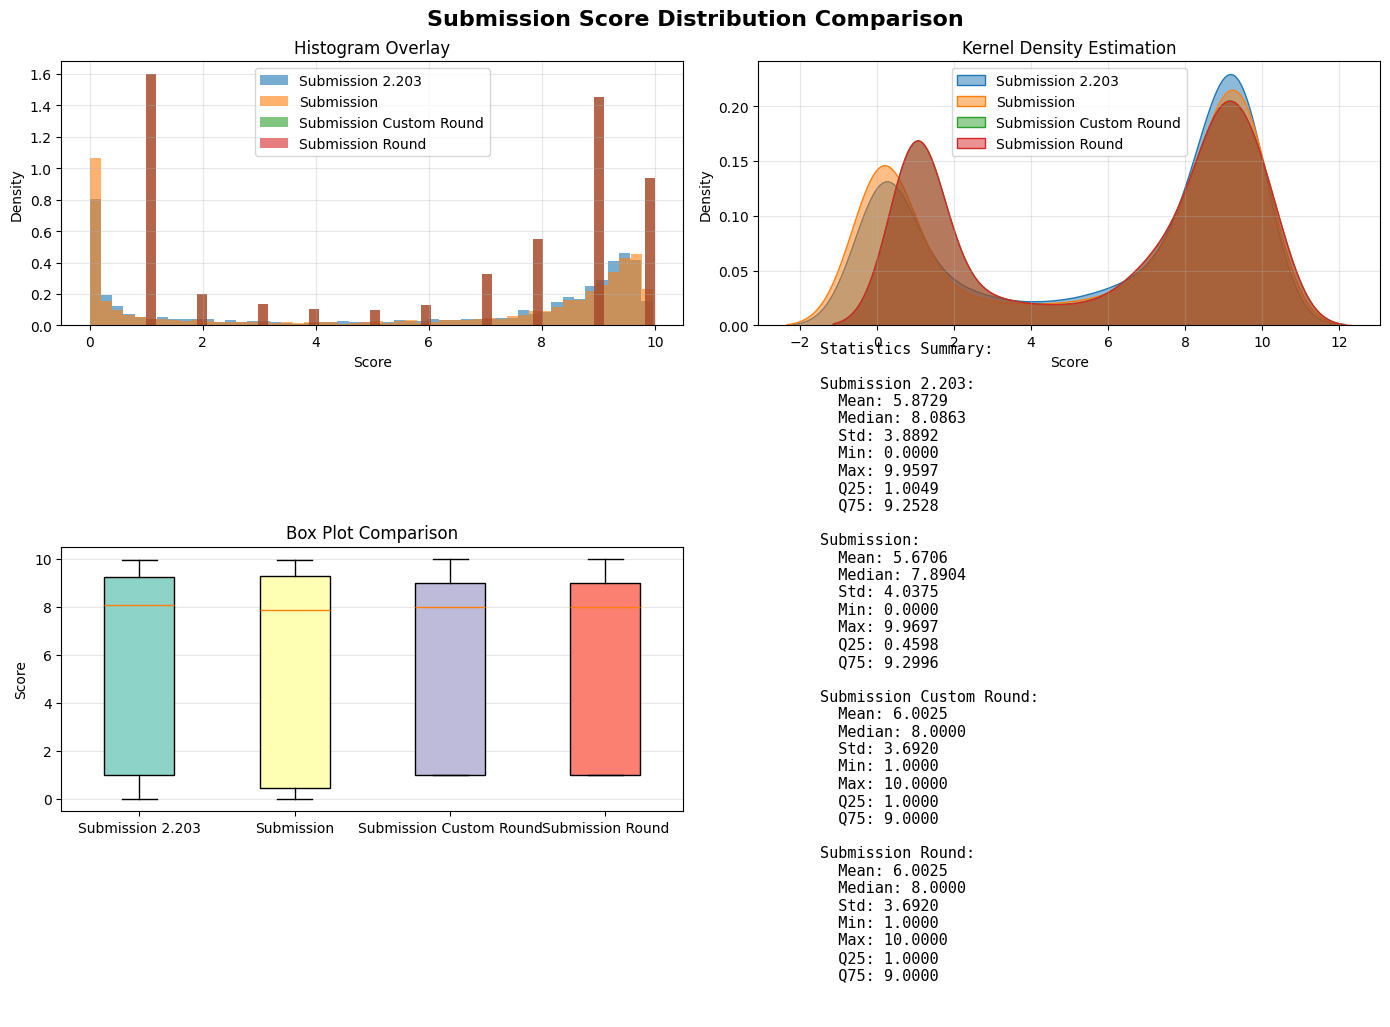

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
def plot_submission_distributions(file_paths, labels, title="Score Distribution Comparison"):
    """
    Plot distribution comparison of multiple submission files.
    
    Parameters:
    -----------
    file_paths : list of str
        Paths to submission CSV files
    labels : list of str
        Labels for each file (for legend)
    title : str
        Plot title
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Load data
    data_dict = {}
    for file_path, label in zip(file_paths, labels):
        df = pd.read_csv(file_path)
        if 'score' in df.columns:
            data_dict[label] = df['score'].values
        else:
            print(f"Warning: 'score' column not found in {file_path}")
            continue
    
    # Plot 1: Histogram overlay
    ax1 = axes[0, 0]
    for label, scores in data_dict.items():
        ax1.hist(scores, bins=50, alpha=0.6, label=label, density=True)
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Density')
    ax1.set_title('Histogram Overlay')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: KDE plot
    ax2 = axes[0, 1]
    for label, scores in data_dict.items():
        sns.kdeplot(scores, ax=ax2, label=label, fill=True, alpha=0.5)
    ax2.set_xlabel('Score')
    ax2.set_ylabel('Density')
    ax2.set_title('Kernel Density Estimation')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Box plot
    ax3 = axes[1, 0]
    plot_data = [scores for scores in data_dict.values()]
    bp = ax3.boxplot(plot_data, labels=list(data_dict.keys()), patch_artist=True)
    for patch, label in zip(bp['boxes'], data_dict.keys()):
        patch.set_facecolor(plt.cm.Set3(list(data_dict.keys()).index(label)))
    ax3.set_ylabel('Score')
    ax3.set_title('Box Plot Comparison')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Statistics summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    stats_text = "Statistics Summary:\n\n"
    for label, scores in data_dict.items():
        stats_text += f"{label}:\n"
        stats_text += f"  Mean: {np.mean(scores):.4f}\n"
        stats_text += f"  Median: {np.median(scores):.4f}\n"
        stats_text += f"  Std: {np.std(scores):.4f}\n"
        stats_text += f"  Min: {np.min(scores):.4f}\n"
        stats_text += f"  Max: {np.max(scores):.4f}\n"
        stats_text += f"  Q25: {np.percentile(scores, 25):.4f}\n"
        stats_text += f"  Q75: {np.percentile(scores, 75):.4f}\n\n"
    ax4.text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
             verticalalignment='center', transform=ax4.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    return data_dict

# Plot distributions
file_paths = ["submission_2_203.csv", "submission.csv", "submission_custom_round.csv", "submission_round.csv"]
labels = ["Submission 2.203", "Submission", "Submission Custom Round", "Submission Round"]
data_dict = plot_submission_distributions(file_paths, labels, 
                                          title="Submission Score Distribution Comparison")
